In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import os
import re
import pandas as pd
from datetime import datetime
from pathlib import Path

In [2]:
data_directory = Path(r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\U-shaped laser\New gen\LEF2\New gen")

# Pattern to match filename such as: no_0_2026-02-26_14-53-05_ESA_cold_cavity.txt
pat = re.compile(
    r"no_(?P<no>\d+)_"
    r"(?P<date>\d{4}-\d{2}-\d{2})_(?P<time>\d{2}-\d{2}-\d{2})_"
    r"(?P<instrument>ESA|OSA|powers)_(?P<state>cold_cavity|injected)\.txt$"
)


# Pattern to extract only what you want from the folder name: 
#"higher" or "lower", voltage "0V", "1V", "2.5V", "2,5V", ..
folder_pat = re.compile(
    r"(?i)\b(?P<scan>higher|lower)\b.*?\b(?P<voltage>\d+(?:[.,]\d+)?)\s*V\b"
)


def parse_parameter(folder_name: str):
    """
    Extract scan direction (higher/lower) and voltage from a folder name like:
      'Data higher wavelength 0V new'  -> scan_dir='higher', voltage_V=0.0
    """
    m = folder_pat.search(folder_name)
    if not m:
        # If parsing fails, return NaNs to identify problematic folders later
        return None, np.nan

    scan_dir = m.group("scan").lower()
    voltage_str = m.group("voltage").replace(",", ".")
    voltage_V = float(voltage_str)

    return scan_dir, voltage_V



rows = []
param_folders = [f for f in data_directory.iterdir() if f.is_dir() and "data" in f.name.lower()]



for folder in param_folders:
    
    scan_dir, voltage_V = parse_parameter(folder.name) #Get scan direction and voltage from the folder name

    
    

    for f in folder.glob("*.txt"): #For each .txt file in data/parameter folder 
        m = pat.match(f.name) #Check the filename follows the pattern or skip to next file if not
        if not m:
            continue 

        d = m.groupdict() #Extract the information from the filename using the regex pattern and store it in a dictionary
        timestamp = f"{d['date']} {d['time'].replace('-',':')}" #Get timestamp


        rows.append({
            "voltage": voltage_V,
            "scan_dir": scan_dir,
            "meas_no_adj": int(d["no"]),
            "timestamp": pd.to_datetime(timestamp),
            "instrument": d["instrument"],
            "state": d["state"],
            "path": str(f),
        }) #Append the extracted information to the list of rows as a dictionary

df = pd.DataFrame(rows).sort_values(["voltage","scan_dir","meas_no_adj","instrument","state"]).reset_index(drop=True) #Create a DataFrame from the list of rows and sort it by parameter, measurement number, instrument, and state. Reset the index after sorting (meaning we don't keep the original indices).
df.head() #Display the first row of the DataFrame to verify that the information has been extracted and organized correctly.


df["timestamp"] = pd.to_datetime(df["timestamp"])

# Working copy to adjust
df["meas_no_raw"] = df["meas_no_adj"].copy()

def parse_cutoff(ts_str: str) -> pd.Timestamp:
    # "2026-02-25_14-58-26" -> Timestamp("2026-02-25 14:58:26")
    date_part, time_part = ts_str.split("_")
    return pd.to_datetime(f"{date_part} {time_part.replace('-',':')}")



In [3]:
#Fix that there are two runs for 1V, so we will put second run right after 1st run for both 1V higher and 1V lower (the measurements are back to back anyway)
cutoff_high = parse_cutoff("2026-02-25_14-58-26")
cutoff_low = parse_cutoff("2026-02-25_15-58-49")

mask_high_run2 = (
    (df["voltage"] == 1.0) &
    (df["scan_dir"] == "higher") &
    (df["timestamp"] > cutoff_high)
)

mask_low_run2 = (
    (df["voltage"] == 1.0) &
    (df["scan_dir"] == "lower") &
    (df["timestamp"] > cutoff_low)
)

df.loc[mask_high_run2, "meas_no_adj"] = df.loc[mask_high_run2, "meas_no_raw"] + 46
df.loc[mask_low_run2, "meas_no_adj"] = df.loc[mask_low_run2, "meas_no_raw"] + 138


df = df.sort_values(["voltage","scan_dir","meas_no_adj","instrument","state"]).reset_index(drop=True)



In [4]:
def lin_to_dB(power):

    return 10*np.log10(power) #dBm really, so we divide with 1mW

def ESA_peak_finder(freq,power): #Returns peak frequency and power

    # [freq,power] = np.loadtxt(file_path,skiprows=1)
    # plt.figure()
    # plt.plot(freq,power)

    DC_cut_off_index = 50

    # plt.plot(freq[DC_cut_off_index:],power[DC_cut_off_index:])

    indices,peak_powers_dict = find_peaks(power[DC_cut_off_index:],height=[-70,0])

    indices += DC_cut_off_index

    if len(indices) == 0:

        return [0.0,-80.0]
    else:
        peak_powers =  peak_powers_dict['peak_heights']

        max_index = int(np.where(peak_powers == np.max(peak_powers))[0][0])

        if peak_powers[max_index] == power[indices[max_index]]:

            return [freq[indices[max_index]],peak_powers[max_index]] 
        
        else:
            print('ESA PEAK FAILURE!')
            return [0,0]
        


def OSA_peak_finder(wavelength,power_lin): #Returns peak wavelength and power

    # data = np.loadtxt(file_path,skiprows=1,delimiter=',')

    # wavelength = data[:,0]

    power = lin_to_dB(np.abs(power_lin))

    # plt.plot(wavelength,power)

    indices,peak_powers_dict = find_peaks(power,height=[-50,0])

    if len(indices) == 0:

        return [0.0,-80.0]
    else:
        peak_powers =  peak_powers_dict['peak_heights']


        max_index = int(np.where(peak_powers == np.max(peak_powers))[0][0])

        if peak_powers[max_index] == power[indices[max_index]]:

            return [wavelength[indices[max_index]],peak_powers[max_index]] 
        
        else:
            print('OSA PEAK FAILURE!')
            return [0,0] 

def powers_splitting_accounted_for(file_path,splitting_factor_follower = 20, splitting_factor_leader=1): #This should be updated (leader is 0.2dB lower than measured and additional losses trough circulator)
    
    data = np.loadtxt(file_path)

    data[0] *= splitting_factor_follower
    data[1] *= splitting_factor_leader

    return data



In [5]:
df["x"] = None          # raw x axis (ESA / OSA)
df["y"] = None          # raw y axis (ESA / OSA)

df["peak_x"] = np.nan   # peak frequency / wavelength
df["peak_y"] = np.nan   # peak power (dB)

df["power_follower"] = np.nan # power of follower in mW (lin)
df["power_leader"] = np.nan # power of leader in mW (lin)

In [6]:
#Apply the peak finder etc. to each row of the DataFrame, depending on the instrument type (ESA, OSA, powers)

for i, row in df.iterrows():
    file_path = row["path"]
    instrument = row["instrument"]
    state = row["state"]

    if instrument == "ESA":
        # ----- RAW DATA -----
        freq, power = np.loadtxt(file_path, skiprows=1)
        
        df.at[i, "x"] = freq
        df.at[i, "y"] = power

        # ----- PEAK -----
        peak_freq, peak_power = ESA_peak_finder(freq, power)
        df.at[i, "peak_x"] = peak_freq
        df.at[i, "peak_y"] = peak_power

    elif instrument == "OSA":
        # ----- RAW DATA -----
        data = np.loadtxt(file_path, skiprows=1, delimiter=",")
        wavelength = data[:, 0]
        power_lin = data[:, 1]

        df.at[i, "x"] = wavelength
        df.at[i, "y"] = power_lin

        # ----- PEAK -----
        peak_wave, peak_power = OSA_peak_finder(wavelength,power_lin)
        df.at[i, "peak_x"] = peak_wave
        df.at[i, "peak_y"] = peak_power

    elif instrument == "powers":
        power_follower, power_leader = powers_splitting_accounted_for(
            file_path, splitting_factor_follower=20, splitting_factor_leader=1       )

        df.at[i, "power_follower"] = power_follower
        df.at[i, "power_leader"] = power_leader


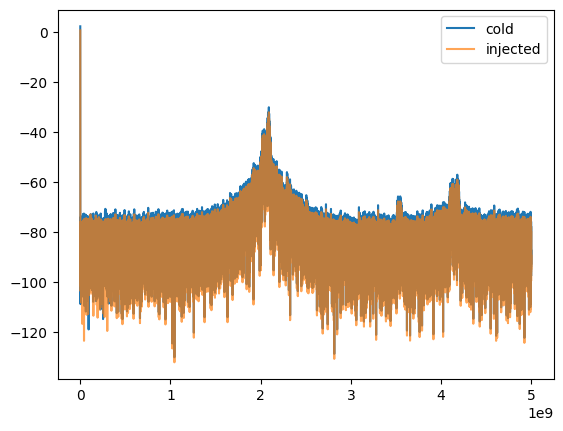

In [7]:
#Example plot of ESA cold cavity vs injected for a specific parameter set
sub = df[
    (df["instrument"] == "ESA") &
    (df["voltage"] == 0) &
    (df["scan_dir"] == "higher") &
    (df["meas_no_adj"] == 38)
]

cold = sub[sub["state"] == "cold_cavity"].iloc[0]
inj  = sub[sub["state"] == "injected"].iloc[0]

plt.plot(cold["x"], cold["y"], label="cold")
plt.plot(inj["x"], inj["y"]-2,  label="injected", alpha=0.7)
plt.legend()
plt.show()

In [8]:
# Select "good" measurements:
# A measurement index is kept only if BOTH ESA injected and cold‑cavity
# beatnote peaks exist (i.e. successful peak detection in both states).
#
# This removes orphan files and failed sweeps.
#
# "Minima indices" = lowest 15% of injected ESA beatnote frequencies.
# These were used as an indicator for stronger locking / frequency pulling.
#
# IMPORTANT:
# Many measurements are not independent (read: ESA measurements are identical for injected and cold-cavity) due to insufficient waiting
# time after switching between injected and cold‑cavity states, so the data should be retaken.


#Should maybe check for all the injection locked state with beatnote of 0.0 GHz
#  and look at how far the cold cavity beatnote is from the injection locked beatnote (0.0 GHz) (max distance of cold cavity beatnote from 0.0 GHz)
#Compare to the other way around, with minimum distance of injection locked state and see the (what should be the) minimum distance of cold cavity beatnote from 0.0 GHz

#Also doublecheck that the good-indices work for peak_x at 0GHz (and check that ESA peak finder returns 0GHz if it can't find a peak)

good_indices = {}     # keyed by (scan_dir, voltage)
minima_indices = {}

for scan in df["scan_dir"].dropna().unique():
    for voltage in sorted(df["voltage"].dropna().unique()):

        sub = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "ESA")
        ]

        if sub.empty:
            continue

        piv = sub.pivot_table(
            index="meas_no_adj",
            columns="state",
            values=["peak_x", "peak_y"],
            aggfunc="first"
        )


        good_mask = (
            piv["peak_x", "cold_cavity"].notna() &
            piv["peak_x", "injected"].notna() &
            (piv["peak_x", "cold_cavity"] != 0.0) &
            (piv["peak_x", "injected"] != 0.0)
        )


        good_idx = np.array(piv.index[good_mask])
        good_indices[(scan, voltage)] = good_idx

        inj_freq = piv.loc[good_idx, ("peak_x", "injected")]
        thr = np.percentile(inj_freq, 15)

        minima_idx = good_idx[inj_freq < thr]
        minima_indices[(scan, voltage)] = minima_idx

        print(f"{scan}, {voltage} V → minima indices:", minima_idx)

higher, 0.0 V → minima indices: [ 9 11 13 22 41 43 45 46 47 48]
higher, 1.0 V → minima indices: [  5   7  29  30  31  32  36  37  40  42  45  48  52  55  57  58  59  62
  63  64  67  88 102 103 104 105 107 113 114 135 199 204 205 206 207 208
 209 211 215 216 217 219 234 245 246 248 249 252 256 259 264 276 279 280
 284 286 344 346 370 371]
higher, 2.5 V → minima indices: [15 17 22 23 35 55 56 57 58]
higher, 3.0 V → minima indices: [16 17 18 19 27 28 29 30 33]
lower, 0.0 V → minima indices: [ 4  5  6  9 63 65 66 67 70 80 81 82 83]
lower, 1.0 V → minima indices: [ 20  40  44  45  52  53  55  56  58  59  61  62  71  74  79  81  82  86
  89  91 100 102 106 107 108 111 112 116 117 120 138 182 183 185 208 256
 260 265 266 268 269]
lower, 2.5 V → minima indices: [ 9 16 17 26 27 29 36 37 42 61]
lower, 3.0 V → minima indices: [ 6 32 33 34 41 46 47 48 55]


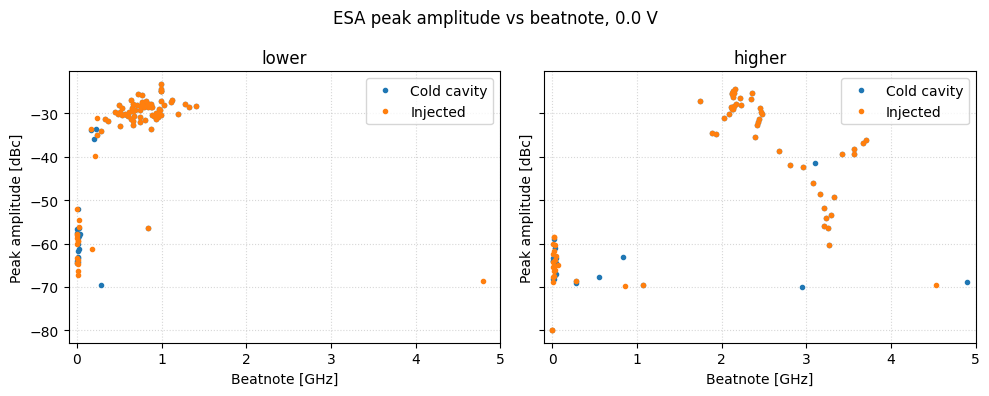

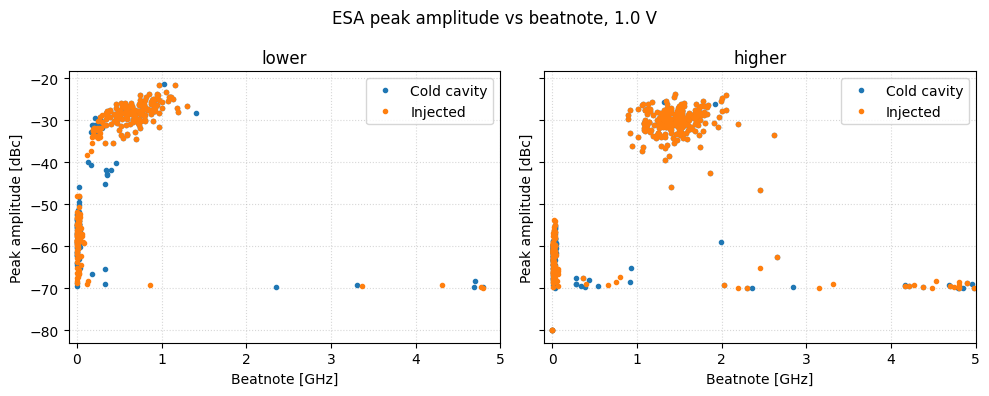

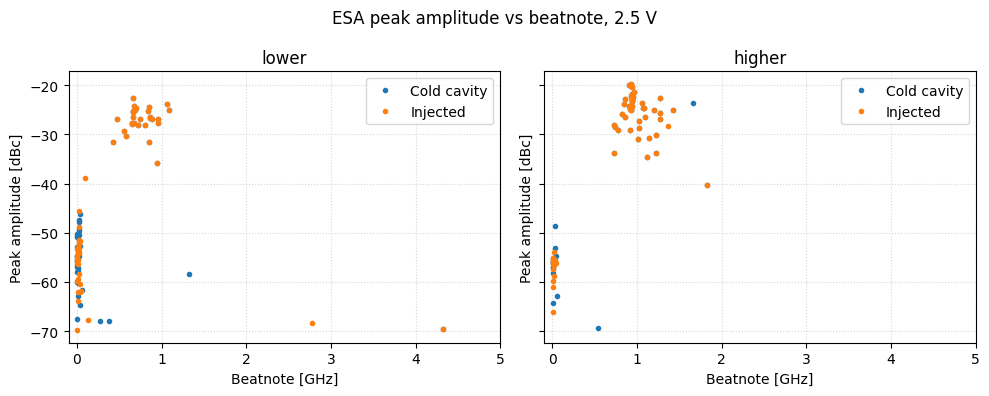

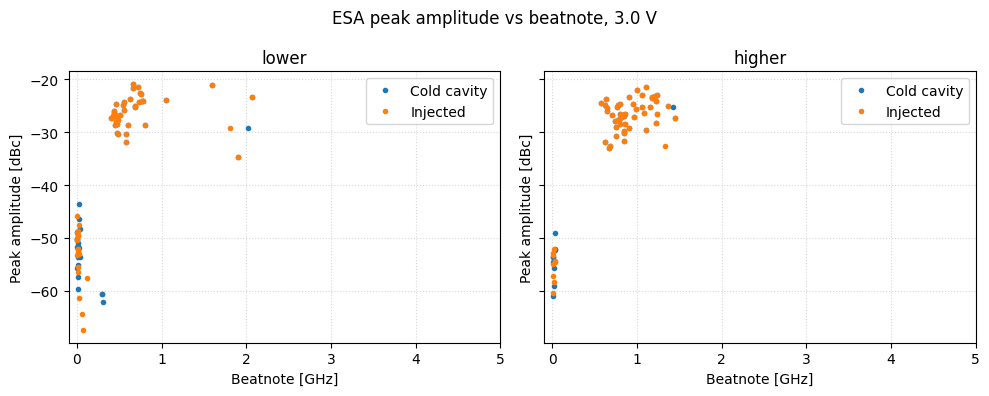

In [21]:
# Diagnostic plot of all ESA peak detections:
#   - cold cavity
#   - injected
#
# Used to visualize scatter, clustering, and stability of the beatnote.
# Dense clusters indicate repeated measurements of nearly the same
# physical state.
#
# No filtering is applied here — this plot is NOT used quantitatively.



for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        sub = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "ESA")
        ]

        piv = sub.pivot_table(
            index="meas_no_adj",
            columns="state",
            values=["peak_x", "peak_y"],
            aggfunc="first"
        )


        ax.plot(
            piv["peak_x", "cold_cavity"] * 1e-9,
            piv["peak_y", "cold_cavity"],
            ".",
            label="Cold cavity"
        )
        ax.plot(
            piv["peak_x", "injected"] * 1e-9,
            piv["peak_y", "injected"],
            ".",
            label="Injected"
        )


        ax.set_title(scan)
        ax.set_xlabel("Beatnote [GHz]")
        ax.set_ylabel("Peak amplitude [dBc]")
        ax.legend()
        ax.set_xlim(-0.1, 5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

    
    fig.suptitle(f"ESA peak amplitude vs beatnote, {voltage} V")
    plt.tight_layout()
    plt.show()


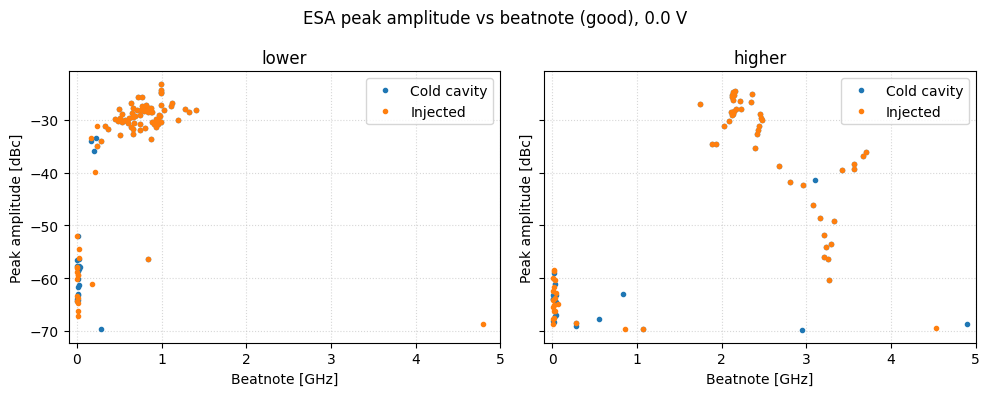

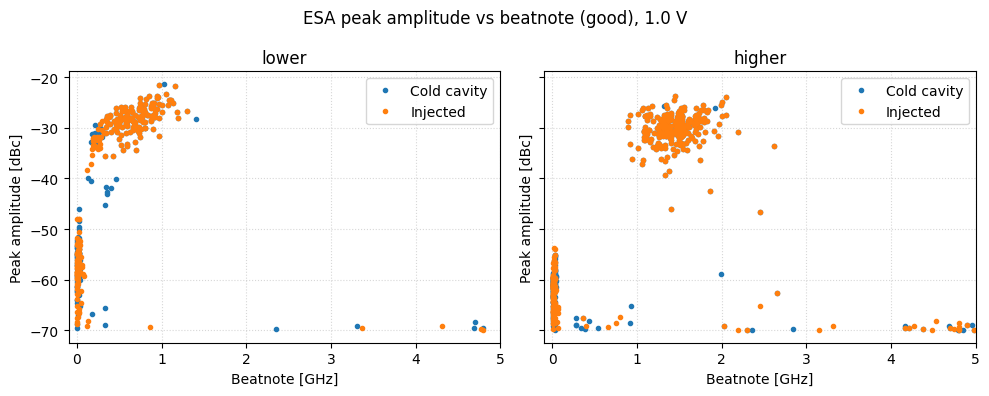

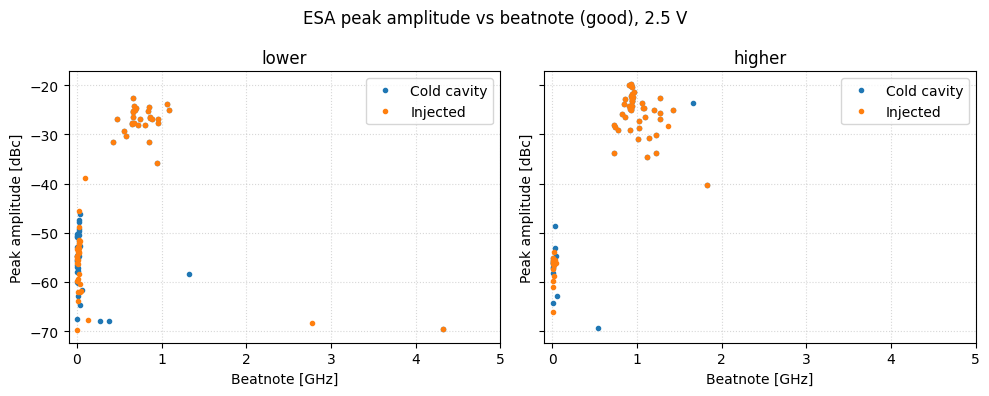

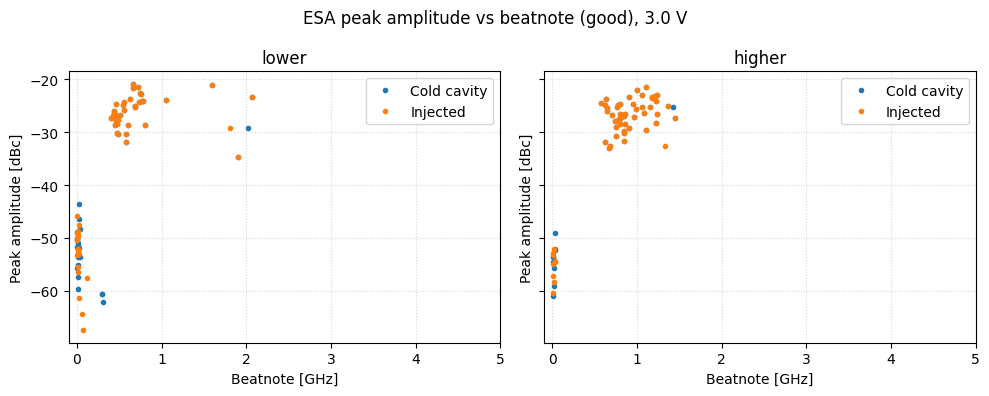

In [22]:
# Same ESA plot as before, but restricted to "good" measurement indices
# where both injected and cold‑cavity peaks are present.
#
# This removes invalid or incomplete sweeps.
#
# Still note:
# Good ≠ independent. Many points probe the same transient state due to too short waiting times between injection lock OFF and ON switches.



for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        good_idx = good_indices[(scan, voltage)]




        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "ESA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values=["peak_x", "peak_y"],
            aggfunc="first"
        )

        
        ax.plot(
            piv.loc[good_idx, ("peak_x", "cold_cavity")] * 1e-9,
            piv.loc[good_idx, ("peak_y", "cold_cavity")],
            ".",
            label="Cold cavity"
        )
        ax.plot(
            piv.loc[good_idx, ("peak_x", "injected")] * 1e-9,
            piv.loc[good_idx, ("peak_y", "injected")],
            ".",
            label="Injected"
        )


        ax.set_title(scan)
        ax.set_xlabel("Beatnote [GHz]")
        ax.set_ylabel("Peak amplitude [dBc]")
        ax.legend()
        ax.set_xlim(-0.1, 5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

    
    fig.suptitle(f"ESA peak amplitude vs beatnote (good), {voltage} V")
    plt.tight_layout()
    plt.show()

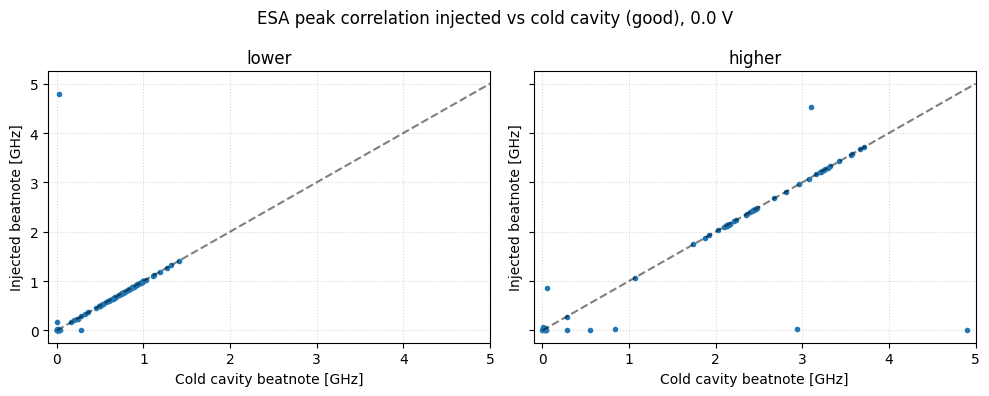

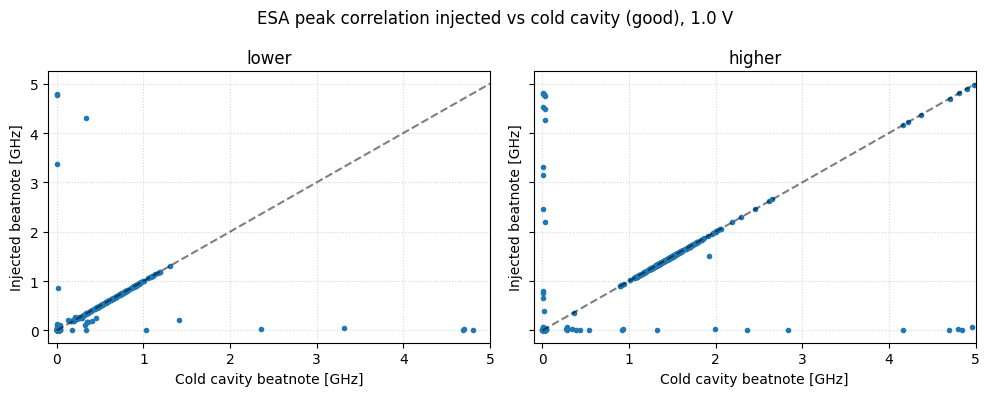

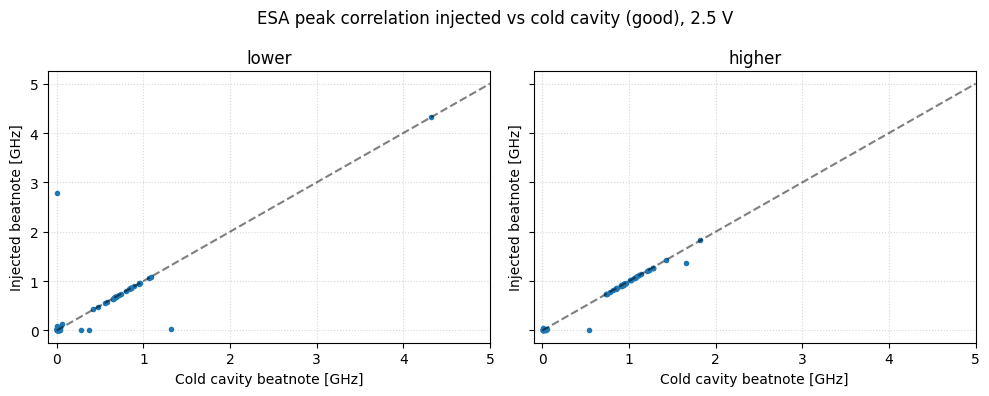

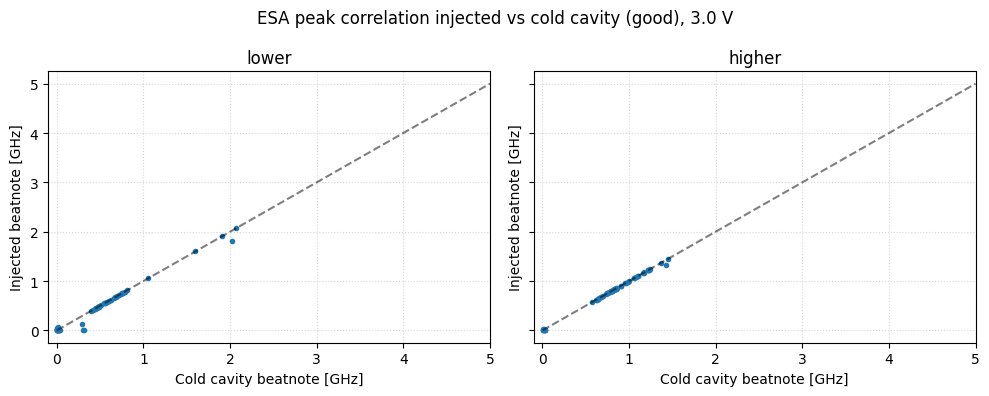

In [23]:
# Correlation plot between cold‑cavity and injected beatnote frequencies.
#
# Physical intent:
# Deviations from the diagonal indicate injection‑induced frequency pulling.
#
# Limitations:
# Due to transient measurements, trends here reflect setup behaviour
# rather than controlled parameter sweeps.


#Seems to be an error in the filtering of good indices, since we have a lot of datapoints near (0,0)


for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        good_idx = good_indices[(scan, voltage)]

        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "ESA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values="peak_x",
            aggfunc="first"
        )

        
        ax.plot(
            piv["cold_cavity"] * 1e-9,
            piv["injected"] * 1e-9,
            "."
        )
        ax.plot([0,5], [0,5], "k--", alpha=0.5, label="Diagonal")  # Diagonal reference line

        ax.set_xlabel("Cold cavity beatnote [GHz]")
        ax.set_ylabel("Injected beatnote [GHz]")

        ax.set_title(scan)

        ax.set_xlim(-0.1, 5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

    
    fig.suptitle(f"ESA peak correlation injected vs cold cavity (good), {voltage} V")
    plt.tight_layout()
    plt.show()

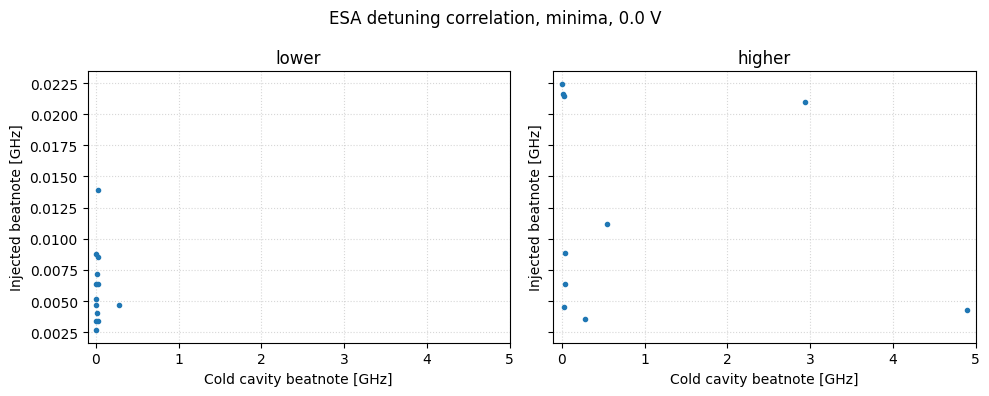

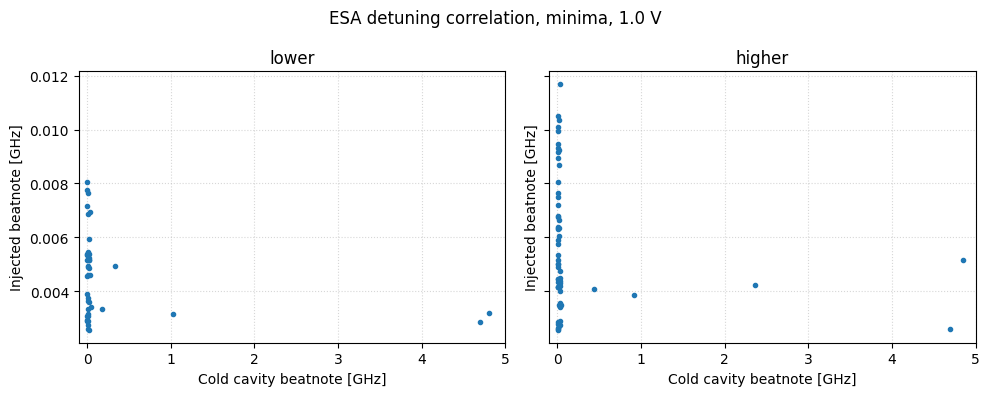

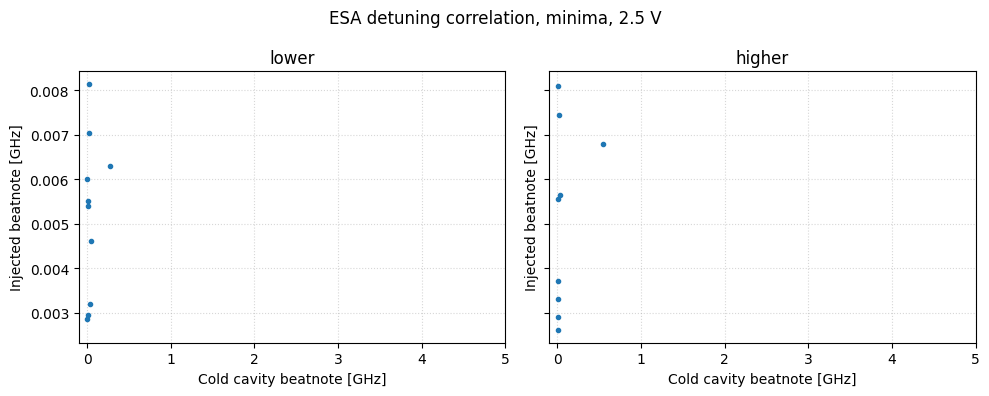

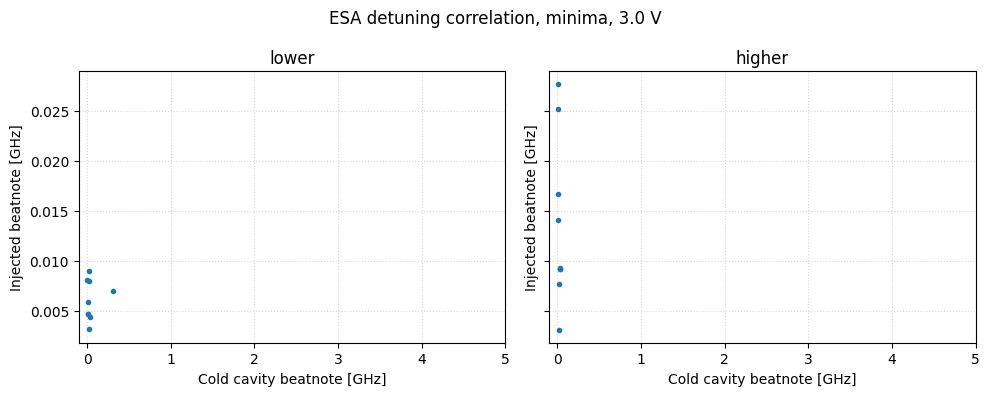

In [25]:
# Plot injected vs cold‑cavity ESA beatnotes,
# restricted to "minima indices" (lowest 15% of injected).
#
# Minima correspond to the lowest injected beatnote frequencies
# (indicator of strongest locking / pulling).
#
# Interpretation is qualitative only


for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        min_idx = minima_indices[(scan, voltage)]


        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "ESA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values="peak_x",
            aggfunc="first"
        )


        ax.plot(
            piv.loc[min_idx, "cold_cavity"] * 1e-9,
            piv.loc[min_idx, "injected"] * 1e-9,
            "."
        )


        ax.set_title(scan)
        ax.set_xlabel("Cold cavity beatnote [GHz]")
        ax.set_ylabel("Injected beatnote [GHz]")
  
        ax.set_xlim(-0.1, 5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

    
    fig.suptitle(f"ESA detuning correlation, minima, {voltage} V")
    plt.tight_layout()
    plt.show()

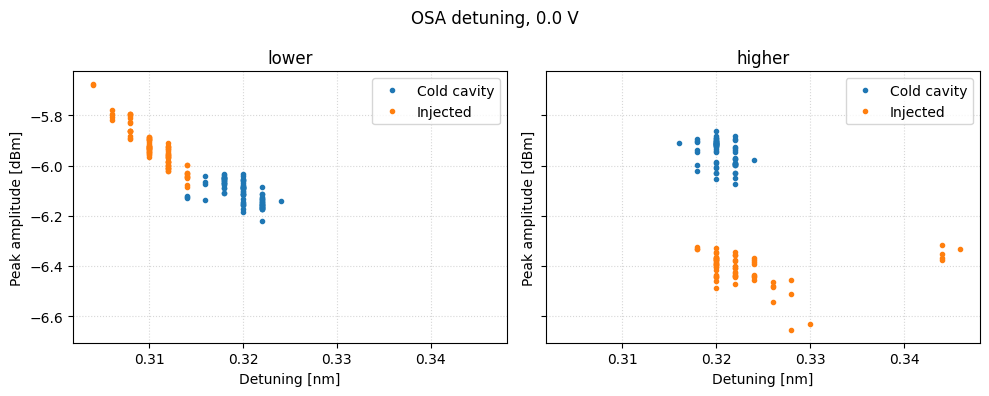

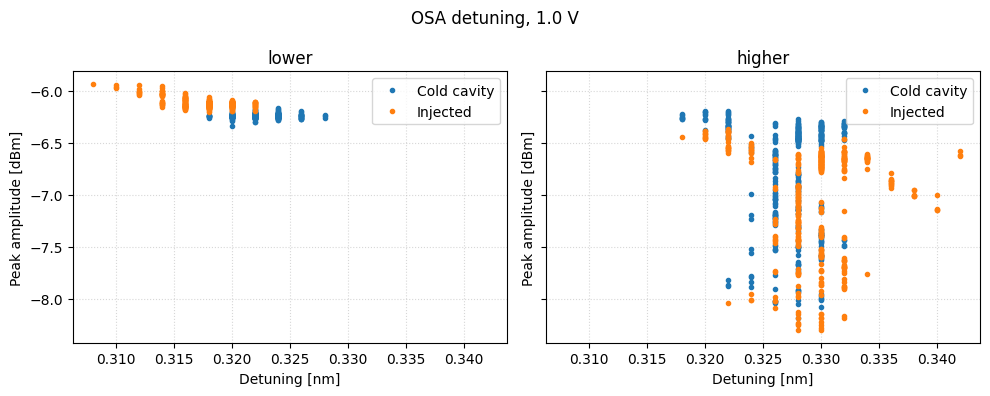

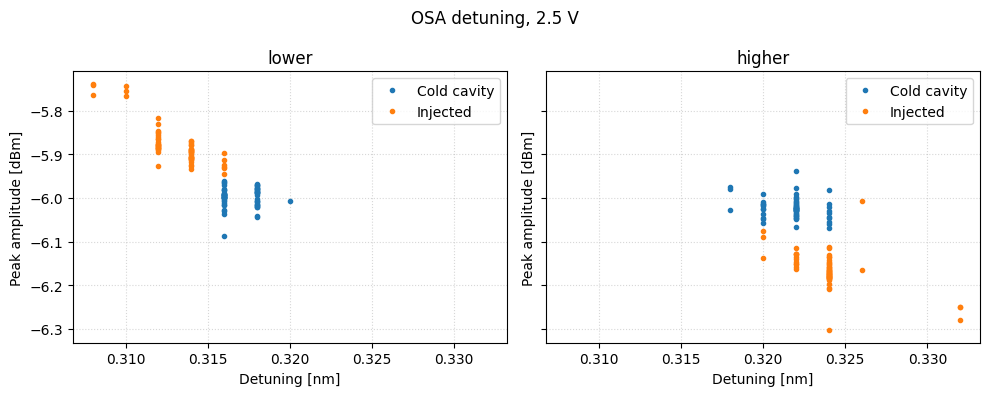

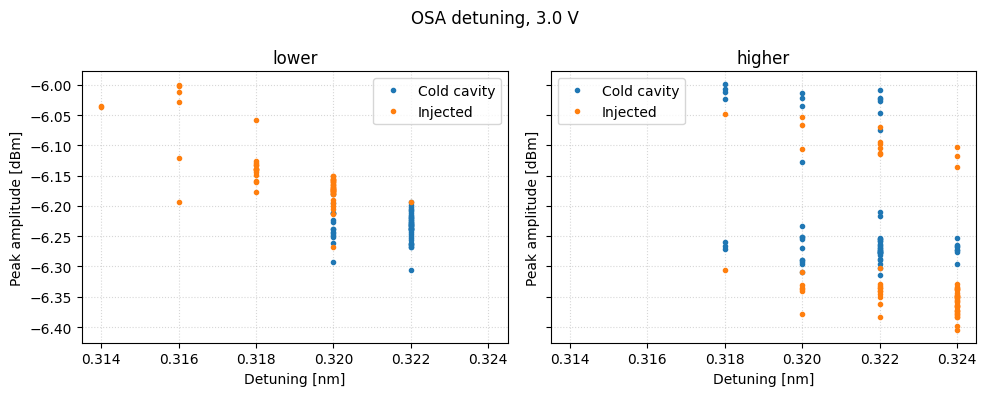

In [ ]:
# OSA peak amplitude vs optical detuning (relative to carrier), good indices
# shown for cold cavity and injected operation.
#
# Used to visualize how injection affects optical spectrum position
# and strength.
#
# OSA resolution is coarse; trends are qualitative.


carrier = 1549.698  # nm


for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        good_idx = good_indices[(scan, voltage)]



        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "OSA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values=["peak_x", "peak_y"],
            aggfunc="first"
        )

        ax.plot(
            piv.loc[good_idx, ("peak_x", "cold_cavity")] - carrier,
            piv.loc[good_idx, ("peak_y", "cold_cavity")],
            ".",
            label="Cold cavity"
        )
        ax.plot(
            piv.loc[good_idx, ("peak_x", "injected")] - carrier,
            piv.loc[good_idx, ("peak_y", "injected")],
            ".",
            label="Injected"
        )


        ax.set_title(scan)
        ax.set_xlabel("Detuning [nm]")
        ax.set_ylabel("Peak amplitude [dBm]")
        ax.legend()
        ax.grid(True, which="both", ls=":", alpha=0.5)

    
    fig.suptitle(f"OSA detuning (good), {voltage} V")
    plt.tight_layout()
    plt.show()
   

20pm difference at 1550nm: 2.4983397645594527 GHz 

Limited by sampling interval (20 pm)!
Resolution ≈ 50 pm


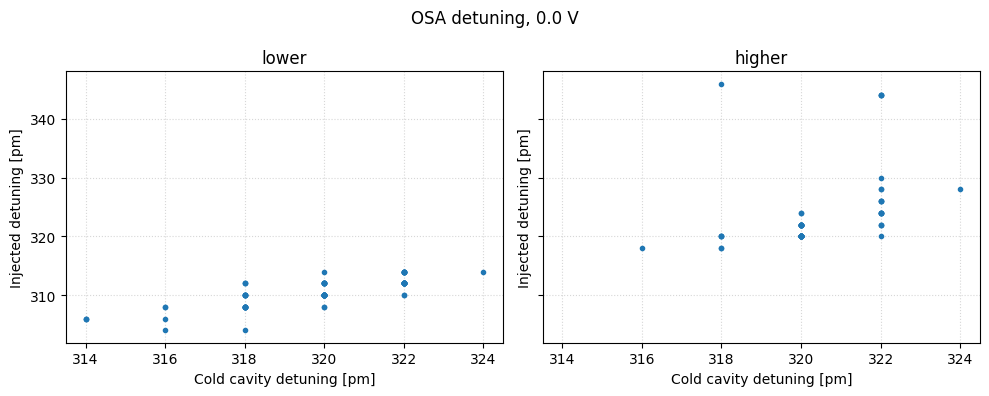

Limited by sampling interval (20 pm)!
Resolution ≈ 50 pm


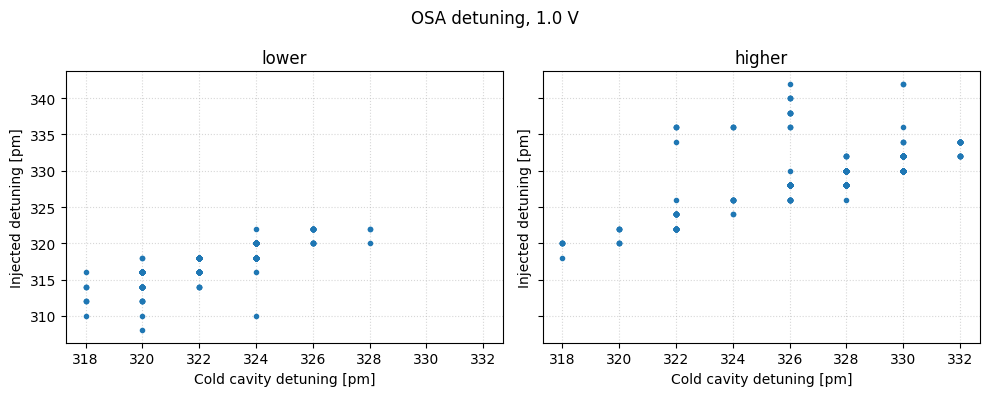

Limited by sampling interval (20 pm)!
Resolution ≈ 50 pm


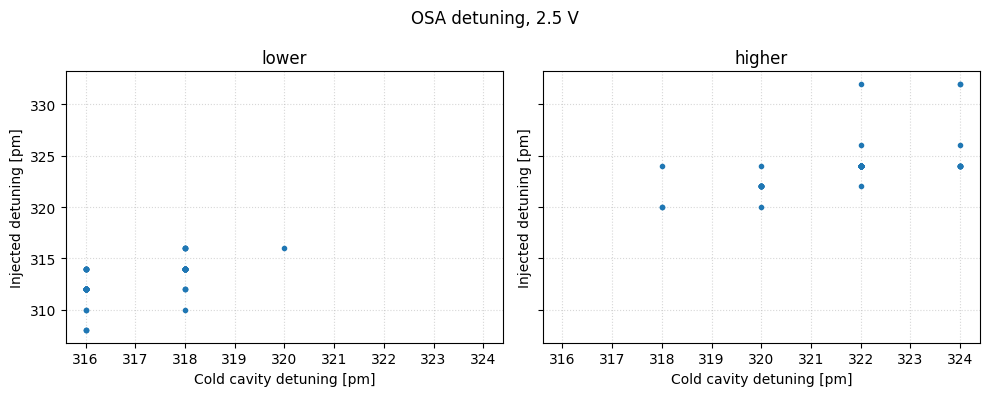

Limited by sampling interval (20 pm)!
Resolution ≈ 50 pm


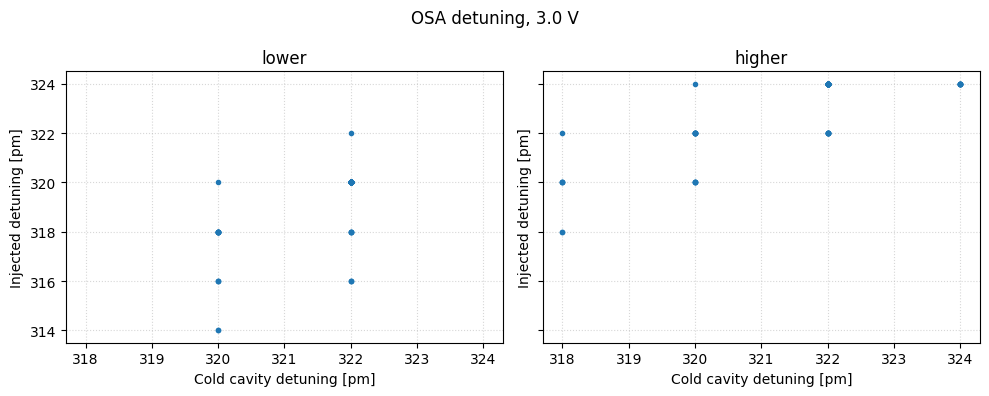

In [29]:
# Correlation between cold‑cavity and injected optical detuning.
#
# Intended to mirror the ESA beatnote correlation plot,
# but at the optical frequency level.
#
# Limited by OSA sampling (~20pm spacing and 50pm resolution).

carrier = 1549.698 #nm
factor = 1e3

c=3*1e8 #m/s

#20pm in GHz
print('20pm difference at 1550nm:',c*(1/carrier - 1/(carrier+0.02)),'GHz','\n')

for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        good_idx = good_indices[(scan, voltage)]

        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "OSA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values="peak_x",
            aggfunc="first"
        )

        ax.plot(
            (piv.loc[good_idx, "cold_cavity"] - carrier) * factor,
            (piv.loc[good_idx, "injected"] - carrier) * factor,
            "."
        )

        ax.set_xlabel("Cold cavity detuning [pm]")
        ax.set_ylabel("Injected detuning [pm]")
        ax.set_title(f"{scan}")
        ax.grid(True, which="both", ls=":", alpha=0.5)

    print("Limited by sampling interval (20 pm)!\nResolution ≈ 50 pm")

    fig.suptitle(f"OSA detuning, {voltage} V")
    plt.tight_layout()
    plt.show()


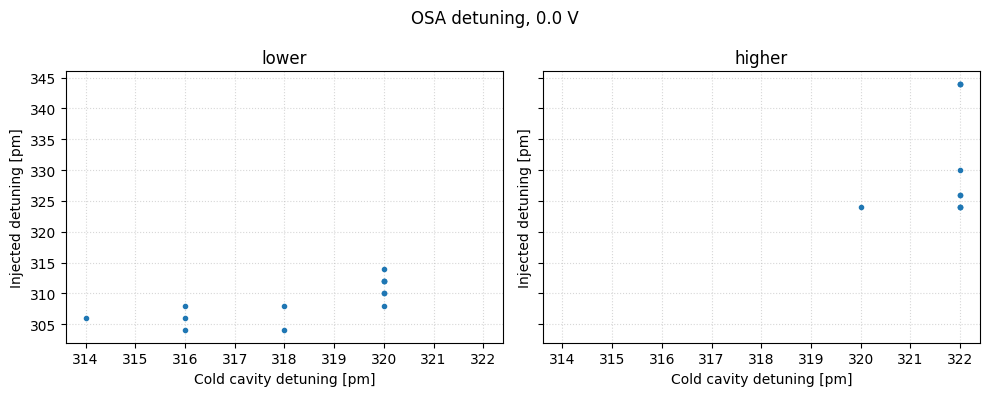

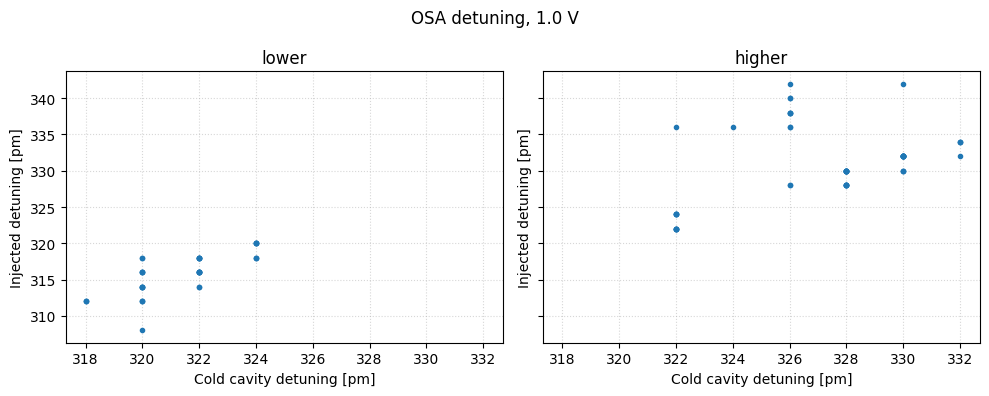

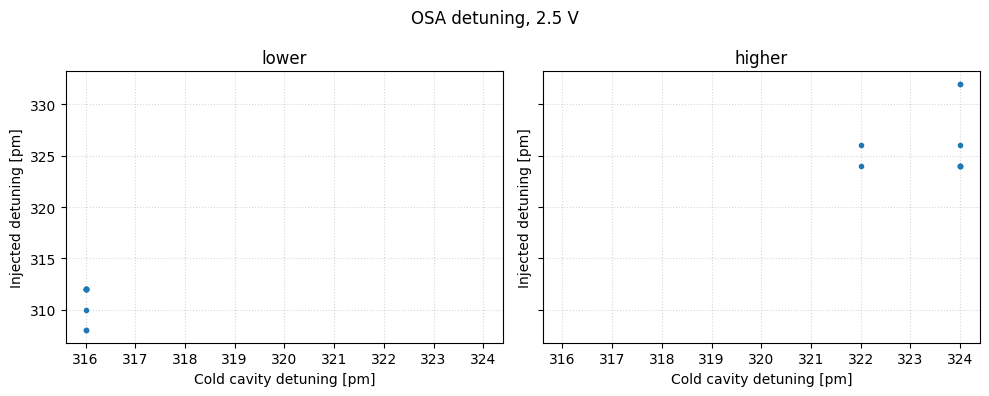

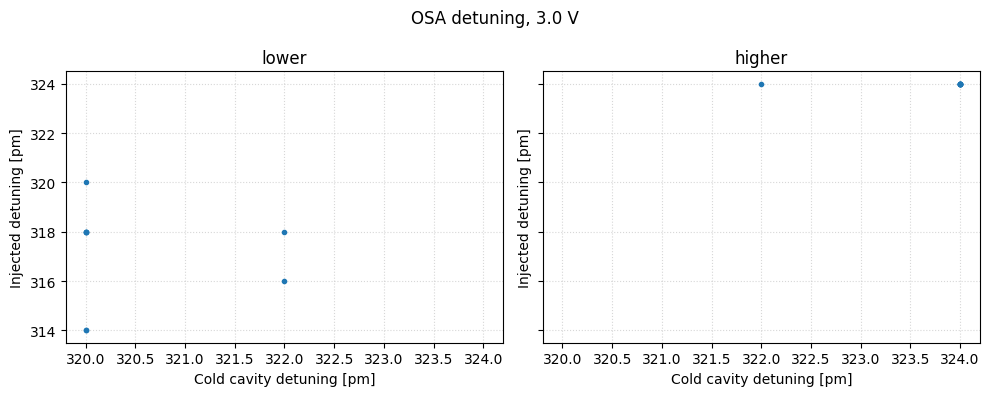

In [30]:
# OSA detuning correlation evaluated only at ESA minima indices.
#
# Intended to check whether strongest ESA locking signatures
# coincide with specific optical detunings.
#
# Qualitative check only; not statistically robust.

carrier = 1549.698
factor = 1e3

for voltage in sorted(df["voltage"].dropna().unique()):

    fig, axes = plt.subplots(
        ncols=2, figsize=(10, 4), sharex=True, sharey=True
    )


    for ax, scan in zip(axes, ["lower", "higher"]):

        min_idx = minima_indices[(scan, voltage)]

        piv = df[
            (df["scan_dir"] == scan) &
            (df["voltage"] == voltage) &
            (df["instrument"] == "OSA")
        ].pivot_table(
            index="meas_no_adj",
            columns="state",
            values="peak_x",
            aggfunc="first"
        )

        ax.plot(
            (piv.loc[min_idx, "cold_cavity"] - carrier) * factor,
            (piv.loc[min_idx, "injected"] - carrier) * factor,
            "."
        )

        
        ax.set_xlabel("Cold cavity detuning [pm]")
        ax.set_ylabel("Injected detuning [pm]")
        ax.set_title(f"{scan}")
        ax.grid(True, which="both", ls=":", alpha=0.5)

    fig.suptitle(f"OSA detuning, {voltage} V")
    plt.tight_layout()
    plt.show()


In [ ]:
np.savetxt(os.path.dirname(directory) + '\\' + '20_12_data.txt', (ESA_injected[:,0], ESA_cold_cavity[:,0], OSA_injected[:,0], OSA_cold_cavity[:,0], pow_follower_injected, pow_leader_injected, pow_follower_cold_cavity, pow_leader_cold_cavity) , header= 'ESA injected beatnote [freq, amplitude] \t ESA cold cavity beatnote [freq, amplitude] \t OSA injected [wavelength, amplitude] \t OSA cold cavity beatnote [wavelength, amplitude] \t Follower power injected \t Leader power injected \t Follower power cold cavity \t Leader power cold cavity')

In [ ]:
data_MZI = pd.read_csv(paths_files[0],engine='python',header=4,delimiter=';',skipfooter=8)

time_MZI_str = list(data_MZI[' Time of day (hh:mm:ss.fff)'])
power_MZI = np.array(list(data_MZI[' Power(W)']))

ParserError: field larger than field limit (131072). Error could possibly be due to parsing errors in the skipped footer rows (the skipfooter keyword is only applied after Python's csv library has parsed all rows).

In [ ]:
time_MZI = np.empty((1,len(time_MZI_str)))[0]

for i,time in enumerate(time_MZI_str):
    tdelta = datetime.strptime(time,'%H:%M:%S.%f') - datetime.strptime(time_MZI_str[0],'%H:%M:%S.%f')

    time_MZI[i] = tdelta.total_seconds() #s


In [ ]:
plt.plot(time_MZI/60,power_MZI*1e6,'.', markersize = 3)

plt.xlabel('Time [min]')
plt.ylabel(r'Power [$\mu$W]')

NameError: name 'time_MZI' is not defined

In [ ]:


# # Assuming the data looks like this:
# # ESA_injected = [[freq1, amp1], [freq2, amp2], ...]
# # ESA_cold_cavity = [[freq1, amp1], [freq2, amp2], ...]
# # OSA_injected = [[wavelength1, amp1], [wavelength2, amp2], ...]
# # pow_follower_injected = [power1, power2, ...]
# # pow_leader_injected = [power1, power2, ...]

# # Convert all columns to strings where necessary
# ESA_injected_str = [f"[{x[0]}, {x[1]}]" for x in ESA_injected]
# ESA_cold_cavity_str = [f"[{x[0]}, {x[1]}]" for x in ESA_cold_cavity]
# OSA_injected_str = [f"[{x[0]}, {x[1]}]" for x in OSA_injected]
# OSA_cold_cavity_str = [f"[{x[0]}, {x[1]}]" for x in OSA_cold_cavity]

# # Combine all data into a single 2D array (list of lists)
# data = np.column_stack((
#     ESA_injected_str,
#     ESA_cold_cavity_str,
#     OSA_injected_str,
#     OSA_cold_cavity_str,
#     pow_follower_injected,
#     pow_leader_injected,
#     pow_follower_cold_cavity,
#     pow_leader_cold_cavity
# ))

# # Save to file
# output_file = os.path.dirname(directory) + '\\' + '20_12_data.txt'
# np.savetxt(output_file, data, fmt='%s', delimiter='\t',
#            header=('ESA injected beatnote [freq, amplitude] \t '
#                    'ESA cold cavity beatnote [freq, amplitude] \t '
#                    'OSA injected [wavelength, amplitude] \t '
#                    'OSA cold cavity beatnote [wavelength, amplitude] \t '
#                    'Follower power injected \t Leader power injected \t '
#                    'Follower power cold cavity \t Leader power cold cavity'))


In [ ]:
# loaded_data = np.loadtxt(output_file, dtype=str, delimiter='\t', skiprows=1)